# EXP: Hypergraph Topologies

In [1]:
import HAT
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
from itertools import combinations
import time
from collections import Counter

In [1]:
import random
import time
import numpy as np
import pandas as pd
import networkx as nx
import HAT

# ============================================================================
# HYPERGRAPH GENERATION FUNCTIONS
# ============================================================================

def random_uniform_hypergraph(n, k, m):
    """Random uniform hypergraph — baseline topology."""
    edge_set = set()
    edge_list = []
    while len(edge_list) < m:
        tail = tuple(sorted(random.sample(range(n), k)))
        remaining = list(set(range(n)) - set(tail))
        hsize = random.randint(1, min(k - 1, len(remaining)))
        head = tuple(sorted(random.sample(remaining, hsize)))
        edge = (head, tail)
        if edge not in edge_set:
            edge_set.add(edge)
            edge_list.append({"head": list(head), "tail": list(tail)})
    return edge_list


def scale_free_hypergraph(n, k, m, gamma=2.5):
    """
    Scale-free hypergraph via preferential attachment.
    Nodes with higher degree are more likely to appear in new hyperedges.
    """
    edge_list = []
    node_degrees = np.zeros(n)

    # Seed with a few random edges so every node has a chance
    num_init = min(5, m)
    for _ in range(num_init):
        tail = random.sample(range(n), k)
        remaining = list(set(range(n)) - set(tail))
        hsize = random.randint(1, min(k - 1, len(remaining)))
        head = random.sample(remaining, hsize)
        edge_list.append({"head": head, "tail": tail})
        for t in tail:
            node_degrees[t] += 1
        for h in head:
            node_degrees[h] += 1

    while len(edge_list) < m:
        probs = (node_degrees + 1) ** gamma
        probs /= probs.sum()
        tail = list(np.random.choice(n, size=k, replace=False, p=probs))

        remaining = list(set(range(n)) - set(tail))
        if len(remaining) == 0:
            continue
        hsize = random.randint(1, min(k - 1, len(remaining)))
        rem_probs = (node_degrees[remaining] + 1) ** gamma
        rem_probs /= rem_probs.sum()
        head = list(np.random.choice(remaining, size=hsize, replace=False, p=rem_probs))

        edge_list.append({"head": head, "tail": tail})
        for t in tail:
            node_degrees[t] += 1
        for h in head:
            node_degrees[h] += 1

    return edge_list


def clustered_hypergraph(n, k, m, num_clusters=5):
    """
    Clustered hypergraph with community structure.
    80 % of edges are intra-cluster; 20 % are inter-cluster bridges.
    """
    edge_list = []
    cluster_size = n // num_clusters
    clusters = [
        list(range(i * cluster_size, min((i + 1) * cluster_size, n)))
        for i in range(num_clusters)
    ]
    # Assign leftover nodes to the last cluster
    for i in range(num_clusters * cluster_size, n):
        clusters[-1].append(i)

    intra_prob = 0.8

    for _ in range(m):
        if random.random() < intra_prob:
            cluster = random.choice(clusters)
            if len(cluster) >= k + 1:
                tail = random.sample(cluster, k)
                remaining = list(set(cluster) - set(tail))
                hsize = random.randint(1, min(k - 1, len(remaining)))
                head = random.sample(remaining, hsize)
            else:                          # cluster too small → fall back
                tail = random.sample(range(n), k)
                remaining = list(set(range(n)) - set(tail))
                hsize = random.randint(1, min(k - 1, len(remaining)))
                head = random.sample(remaining, hsize)
        else:                              # inter-cluster edge
            tail = random.sample(range(n), k)
            remaining = list(set(range(n)) - set(tail))
            hsize = random.randint(1, min(k - 1, len(remaining)))
            head = random.sample(remaining, hsize)

        edge_list.append({"head": head, "tail": tail})

    return edge_list


def small_world_hypergraph(n, k, m, rewire_prob=0.1):
    """
    Small-world hypergraph: ring-lattice base with probabilistic rewiring.
    Each node connects to its k nearest neighbours on the ring; with
    probability *rewire_prob* one tail node is replaced by a random node,
    creating long-range shortcuts.
    """
    edge_list = []

    # Walk around the ring, emitting edges until we have m
    total_edges = 0
    while total_edges < m:
        for center in range(n):
            # k nearest neighbours on the ring form the tail
            neighbors = [(center + offset) % n for offset in range(1, k + 1)]
            tail = list(neighbors)                          # copy
            remaining = list(set(range(n)) - set(tail) - {center})

            if len(remaining) == 0:
                continue

            # Head: choose a nearby node, but rewire with probability rewire_prob
            if random.random() < rewire_prob:
                head = [random.choice(remaining)]           # long-range shortcut
            else:
                # Prefer nodes close to center on the ring
                nearby = [(center + off) % n for off in range(-2 * k, 2 * k + 1)]
                nearby_remaining = [x for x in nearby if x in remaining]
                if nearby_remaining:
                    head = [random.choice(nearby_remaining)]
                else:
                    head = [random.choice(remaining)]

            edge_list.append({"head": head, "tail": tail})
            total_edges += 1
            if total_edges >= m:
                break

    return edge_list


# ============================================================================
# STRUCTURAL ANALYSIS
# ============================================================================

def compute_node_centralities(HG):
    """
    Compute degree, closeness, betweenness, and clustering for every node.

    Betweenness is computed on the clique-expanded (undirected) graph — i.e.
    every pair of nodes sharing a hyperedge gets an edge.  This is the
    standard projection used for hypergraph centrality.
    """
    n = HG.nnodes

    # --- build clique-expanded adjacency (used for closeness, betweenness, clustering) ---
    adj_list = [set() for _ in range(n)]
    for _, edge in HG.edges.iterrows():
        for i in edge['head']:
            for j in edge['tail']:
                adj_list[j].add(i)

    # --- degree centrality (number of hyperedges the node participates in) ---
    in_degree = np.zeros(n)
    out_degree = np.zeros(n)
    for _, edge in HG.edges.iterrows():
        for node in edge['head']:
            in_degree[node] += 1
        for node in edge['tail']:
            out_degree[node] += 1

    # --- closeness centrality (BFS on clique-expanded graph) ---
    closeness = np.zeros(n)
    for i in range(n):
        distances = [-1] * n
        distances[i] = 0
        queue = [i]
        idx = 0
        while idx < len(queue):
            u = queue[idx]; idx += 1
            for v in adj_list[u]:
                if distances[v] == -1:
                    distances[v] = distances[u] + 1
                    queue.append(v)
        total_dist = sum(d for d in distances if d > 0)
        if total_dist > 0:
            closeness[i] = (n - 1) / total_dist

    # --- betweenness centrality (networkx on clique-expanded graph) ---
    G_exp = nx.Graph()
    G_exp.add_nodes_from(range(n))
    for i in range(n):
        for j in adj_list[i]:
            G_exp.add_edge(i, j)
    bet_dict = nx.betweenness_centrality(G_exp, normalized=True)
    betweenness = np.array([bet_dict[i] for i in range(n)])

    # --- local clustering coefficient ---
    clustering = np.zeros(n)
    for i in range(n):
        nbrs = list(adj_list[i])
        if len(nbrs) < 2:
            continue
        possible = len(nbrs) * (len(nbrs) - 1) / 2.0
        actual = 0
        for a in range(len(nbrs)):
            for b in range(a + 1, len(nbrs)):
                if nbrs[b] in adj_list[nbrs[a]]:
                    actual += 1
        clustering[i] = actual / possible

    return {
        'in_degree':    in_degree,
        'out_degree':   out_degree,
        'closeness':    closeness,
        'betweenness':  betweenness,
        'clustering':   clustering,
    }


# ============================================================================
# ALGORITHM IMPLEMENTATIONS  (unchanged from your original)
# ============================================================================

def star_graph(HG):
    G = nx.DiGraph() if HG.directed else nx.Graph()
    system_nodes = [f"n{i}" for i in range(HG.nnodes)]
    G.add_nodes_from(system_nodes, bipartite=0)
    for edge_id in HG.edges.index:
        e_node = f"e{edge_id}"
        G.add_node(e_node, bipartite=1)
        heads = [f"n{h}" for h in HG.edges.loc[edge_id, "head"]]
        tails = [f"n{t}" for t in HG.edges.loc[edge_id, "tail"]]
        if HG.directed:
            for t in tails:
                G.add_edge(t, e_node)
            for h in heads:
                G.add_edge(e_node, h)
        else:
            for v in heads + tails:
                G.add_edge(e_node, v)
    return G


def edge_list_to_incidence(edge_list):
    nodes = set()
    for e in edge_list:
        nodes.update(e["head"])
        nodes.update(e["tail"])
    nodes = sorted(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)
    m = len(edge_list)
    incidence = np.zeros((n, m), dtype=int)
    for j, e in enumerate(edge_list):
        for h in e["head"]:
            incidence[node_to_idx[h], j] = 1
        for t in e["tail"]:
            incidence[node_to_idx[t], j] = -1
    return incidence


def detect_dilation_and_drivers(HG, num_nodes):
    from networkx.algorithms import bipartite
    G_star = star_graph(HG)
    G_bip = nx.Graph()
    E_side = set()
    V_side = set()
    for u, v in G_star.edges():
        if isinstance(u, str) and u.startswith("e") \
           and isinstance(v, str) and v.startswith("n"):
            G_bip.add_edge(u, v)
            E_side.add(u)
            V_side.add(v)
    matching = bipartite.hopcroft_karp_matching(G_bip, E_side)
    matched_heads = {
        int(v[1:]) for v in matching
        if isinstance(v, str) and v.startswith("n")
    }
    all_nodes = set(range(HG.nnodes))
    driver_nodes = all_nodes - matched_heads
    dilation_exists = len(matched_heads) < num_nodes
    return dilation_exists, matched_heads, driver_nodes, matching


def add_node_fields(HG):
    HG.nodes["edges"] = [[] for _ in range(len(HG.nodes))]
    HG.nodes["head"]  = [[] for _ in range(len(HG.nodes))]
    HG.nodes["tail"]  = [[] for _ in range(len(HG.nodes))]
    node_to_idx = dict(zip(HG.nodes["Nodes"], HG.nodes.index))
    for _, edge_row in HG.edges.iterrows():
        edge_id = edge_row["Edges"]
        for nd in edge_row["Nodes"]:
            HG.nodes.at[node_to_idx[nd], "edges"].append(edge_id)
        for nd in edge_row["head"]:
            HG.nodes.at[node_to_idx[nd], "head"].append(edge_id)
        for nd in edge_row["tail"]:
            HG.nodes.at[node_to_idx[nd], "tail"].append(edge_id)
    return HG


def greedy_accessibility(HG, initial_drivers=[]):
    all_sys_nodes = set(range(HG.nnodes))
    edge_tails  = [set(t) for t in HG.edges["tail"].tolist()]
    edge_heads  = [set(h) for h in HG.edges["head"].tolist()]
    node_edges_list = HG.nodes['edges'].tolist()
    edge_missing = [set(tail) for tail in edge_tails]

    current_drivers = set(initial_drivers)
    accessible = set(current_drivers)
    active_edges = set()

    for node in list(accessible):
        for edge_idx in node_edges_list[node]:
            edge_missing[edge_idx].discard(node)
            if not edge_missing[edge_idx] and edge_idx not in active_edges:
                active_edges.add(edge_idx)
                accessible.update(edge_heads[edge_idx])

    remaining = all_sys_nodes - (accessible & all_sys_nodes)

    while remaining:
        best_node = None
        best_size = len(remaining)
        best_new_accessible = None

        for cand in remaining:
            new_accessible = accessible | {cand}
            newly_activated = []
            for edge_idx in node_edges_list[cand]:
                if edge_idx not in active_edges:
                    if edge_missing[edge_idx] <= new_accessible:
                        newly_activated.append(edge_idx)
            if newly_activated:
                new_accessible = _fast_propagate(
                    new_accessible, newly_activated, active_edges,
                    edge_missing, edge_heads, node_edges_list
                )
            new_rem = len(all_sys_nodes - (new_accessible & all_sys_nodes))
            if new_rem < best_size:
                best_node        = cand
                best_size        = new_rem
                best_new_accessible = new_accessible

        current_drivers.add(best_node)
        accessible = best_new_accessible
        for edge_idx in node_edges_list[best_node]:
            edge_missing[edge_idx].discard(best_node)
            if not edge_missing[edge_idx] and edge_idx not in active_edges:
                active_edges.add(edge_idx)
        remaining = all_sys_nodes - (accessible & all_sys_nodes)

    return current_drivers


def _fast_propagate(accessible, newly_activated, already_active,
                    edge_missing, edge_heads, node_edges_list):
    result = set(accessible)
    to_process = list(newly_activated)
    processed  = set(already_active)
    i = 0
    while i < len(to_process):
        edge_idx = to_process[i]; i += 1
        processed.add(edge_idx)
        new_nodes = edge_heads[edge_idx] - result
        result.update(new_nodes)
        for node in new_nodes:
            for check_idx in node_edges_list[node]:
                if check_idx not in processed:
                    if edge_missing[check_idx].issubset(result):
                        to_process.append(check_idx)
                        processed.add(check_idx)
    return result


# ============================================================================
# MAIN EXPERIMENT
# ============================================================================

def run_topology_experiment(topology_type, n, k, m, trial_id):
    """
    Run one trial.  Returns:
        summary_row  – one-row dict with aggregate stats (written to summary CSV)
        node_rows    – list of per-node dicts (written to long-form CSV for plotting)
    """
    # --- generate ---
    generators = {
        'random':      lambda: random_uniform_hypergraph(n, k, m),
        'scale_free':  lambda: scale_free_hypergraph(n, k, m, gamma=2.5),
        'clustered':   lambda: clustered_hypergraph(n, k, m, num_clusters=5),
        'small_world': lambda: small_world_hypergraph(n, k, m, rewire_prob=0.1),
    }
    if topology_type not in generators:
        raise ValueError(f"Unknown topology: {topology_type}")
    edge_list = generators[topology_type]()

    # --- build HG object ---
    incidence = edge_list_to_incidence(edge_list)
    nodes_df  = pd.DataFrame({'Nodes': np.arange(n)})
    HG = HAT.Hypergraph(incidence_matrix=incidence, directed=True, nodes=nodes_df)
    HG = add_node_fields(HG)

    # --- centralities (all nodes) ---
    centralities = compute_node_centralities(HG)

    # --- matching ---
    t0 = time.perf_counter()
    dilation_exists, matched_nodes, driver_nodes_match, _ = \
        detect_dilation_and_drivers(HG, HG.nnodes)
    t_matching = time.perf_counter() - t0

    if dilation_exists:
        unmatched = {int(str(u).replace("n", "")) for u in driver_nodes_match}
    else:
        unmatched = {0}

    # --- match + greedy ---
    t0 = time.perf_counter()
    drivers_mg = greedy_accessibility(HG, unmatched)
    t_mg = time.perf_counter() - t0 + t_matching

    # --- pure greedy ---
    t0 = time.perf_counter()
    drivers_pg = greedy_accessibility(HG, set())
    t_pg = time.perf_counter() - t0

    # --- summary row (same structure as before, plus betweenness) ---
    def _ratios(driver_set):
        dl = list(driver_set)
        out = {}
        for metric, vals in centralities.items():
            dv = vals[dl]
            out[f'mean_{metric}']  = np.mean(dv)
            out[f'ratio_{metric}'] = np.mean(dv) / (np.mean(vals) + 1e-10)
        return out

    match_props = _ratios(unmatched)
    mg_props    = _ratios(drivers_mg)
    pg_props    = _ratios(drivers_pg)

    summary_row = {
        'topology': topology_type, 'n': n, 'k': k, 'm': m,
        'alpha': m / n, 'trial_id': trial_id,
        'matching_size':    len(unmatched),
        'greedy_size':      len(drivers_mg),
        'pure_greedy_size': len(drivers_pg),
        'time_matching': t_matching, 'time_mg': t_mg, 'time_pg': t_pg,
    }
    for prefix, props in [('match', match_props), ('mg', mg_props), ('pg', pg_props)]:
        for key, val in props.items():
            summary_row[f'{prefix}_{key}'] = val

    # --- per-node long-form rows (new — needed for Fig 2 distributions) ---
    node_rows = []
    for nd in range(n):
        node_rows.append({
            'topology':      topology_type,
            'alpha':         m / n,
            'trial_id':      trial_id,
            'node_id':       nd,
            'in_degree':     centralities['in_degree'][nd],
            'out_degree':     centralities['out_degree'][nd],
            'closeness':     centralities['closeness'][nd],
            'betweenness':   centralities['betweenness'][nd],
            'clustering':    centralities['clustering'][nd],
            'is_driver_match': nd in unmatched,
            'is_driver_mg':    nd in drivers_mg,
            'is_driver_pg':    nd in drivers_pg,
        })

    return summary_row, node_rows


# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("TOPOLOGY EXPERIMENT — Driver Node Placement Analysis")
    print("=" * 70)

    n   = 100
    k   = 4
    # Expanded alpha range for smooth curves in Fig 1
    alpha_values = [0.5, 0.75, 1, 1.5, 2, 3, 5, 7.5, 10]
    topologies   = ['scale_free', 'clustered', 'small_world']
    num_trials   = 10

    all_summary = []
    all_nodes   = []
    trial_counter = 0

    for topology in topologies:
        print(f"\nTesting topology: {topology}")
        print("-" * 70)

        for alpha in alpha_values:
            m = int(alpha * n)
            print(f"  α={alpha} (m={m})")

            for trial in range(num_trials):
                trial_counter += 1
                try:
                    summary_row, node_rows = run_topology_experiment(
                        topology, n, k, m, trial_counter
                    )
                    all_summary.append(summary_row)
                    all_nodes.extend(node_rows)

                    # Incremental save (summary only — node CSV written at end)
                    pd.DataFrame(all_summary).to_csv('EXP_topology.csv', index=False)

                    print(f"    Trial {trial+1}/{num_trials}: "
                          f"Match={summary_row['matching_size']}, "
                          f"MG={summary_row['greedy_size']}, "
                          f"PG={summary_row['pure_greedy_size']}")
                except Exception as e:
                    print(f"    Trial {trial+1}/{num_trials} FAILED: {e}")
                    import traceback; traceback.print_exc()
                    continue

    # --- write both CSVs ---
    pd.DataFrame(all_summary).to_csv('EXP_topology.csv',       index=False)
    pd.DataFrame(all_nodes).to_csv('EXP_topology_nodes.csv',   index=False)

    print("\n" + "=" * 70)
    print("EXPERIMENT COMPLETE")
    print("=" * 70)
    print(f"Trials completed : {len(all_summary)}")
    print(f"Summary CSV      : EXP_topology.csv")
    print(f"Per-node CSV     : EXP_topology_nodes.csv  ({len(all_nodes)} rows)")

TOPOLOGY EXPERIMENT — Driver Node Placement Analysis

Testing topology: scale_free
----------------------------------------------------------------------
  α=0.5 (m=50)
    Trial 1/10: Match=76, MG=84, PG=84
    Trial 2/10: Match=73, MG=75, PG=76
    Trial 3/10: Match=72, MG=79, PG=81
    Trial 4/10: Match=74, MG=78, PG=82
    Trial 5/10: Match=75, MG=79, PG=85
    Trial 6/10: Match=77, MG=79, PG=82
    Trial 7/10: Match=75, MG=79, PG=82
    Trial 8/10: Match=83, MG=84, PG=87
    Trial 9/10: Match=73, MG=83, PG=87
    Trial 10/10: Match=82, MG=84, PG=87
  α=0.75 (m=75)
    Trial 1/10: Match=79, MG=83, PG=86
    Trial 2/10: Match=67, MG=72, PG=76
    Trial 3/10: Match=74, MG=82, PG=80
    Trial 4/10: Match=75, MG=81, PG=83
    Trial 5/10: Match=74, MG=83, PG=81
    Trial 6/10: Match=73, MG=83, PG=81
    Trial 7/10: Match=72, MG=76, PG=77
    Trial 8/10: Match=77, MG=79, PG=87
    Trial 9/10: Match=76, MG=77, PG=79
    Trial 10/10: Match=80, MG=86, PG=88
  α=1 (m=100)
    Trial 1/10: Mat

In [2]:
df = pd.read_csv('EXP_topology.csv')
df

,topology,n,k,m,alpha,trial_id,matching_size,greedy_size,pure_greedy_size,time_matching,...,pg_mean_in_degree,pg_ratio_in_degree,pg_mean_out_degree,pg_ratio_out_degree,pg_mean_closeness,pg_ratio_closeness,pg_mean_betweenness,pg_ratio_betweenness,pg_mean_clustering,pg_ratio_clustering
0,scale_free,100,4,50,0.5,1,76,84,84,0.002056,...,0.559524,0.570943,1.226190,0.638641,1.587256,0.623487,0.000861,0.606168,0.071606,0.753401
1,scale_free,100,4,50,0.5,2,73,75,76,0.001703,...,0.197368,0.184456,0.828947,0.414474,1.712552,1.050944,0.000506,0.212996,0.119298,0.665197
2,scale_free,100,4,50,0.5,3,72,79,81,0.001618,...,0.407407,0.428850,1.395062,0.697531,1.579964,1.033192,0.000853,0.520341,0.069731,0.694310
3,scale_free,100,4,50,0.5,4,74,78,82,0.001616,...,0.304878,0.320924,0.963415,0.481707,0.343590,0.534063,0.000446,0.362132,0.081995,0.583940
4,scale_free,100,4,50,0.5,5,75,79,85,0.001761,...,0.588235,0.612745,1.517647,0.758824,3.865344,1.096897,0.001414,0.752234,0.047390,0.629998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,small_world,100,4,1000,10.0,266,1,4,4,0.018287,...,6.750000,0.919619,31.000000,1.055858,0.468114,0.960001,0.007083,0.918509,0.496364,1.292912
266,small_world,100,4,1000,10.0,267,1,4,4,0.018233,...,9.250000,1.236631,28.000000,0.935829,0.430720,0.905449,0.013975,1.753983,0.504902,1.241700
267,small_world,100,4,1000,10.0,268,1,4,4,0.018686,...,7.250000,0.966667,29.500000,0.983333,0.543703,1.109833,0.009688,1.251874,0.379836,0.962907
268,small_world,100,4,1000,10.0,269,1,4,4,0.018421,...,6.250000,0.850340,29.250000,0.994898,0.452894,0.962044,0.005578,0.674075,0.502737,1.226016


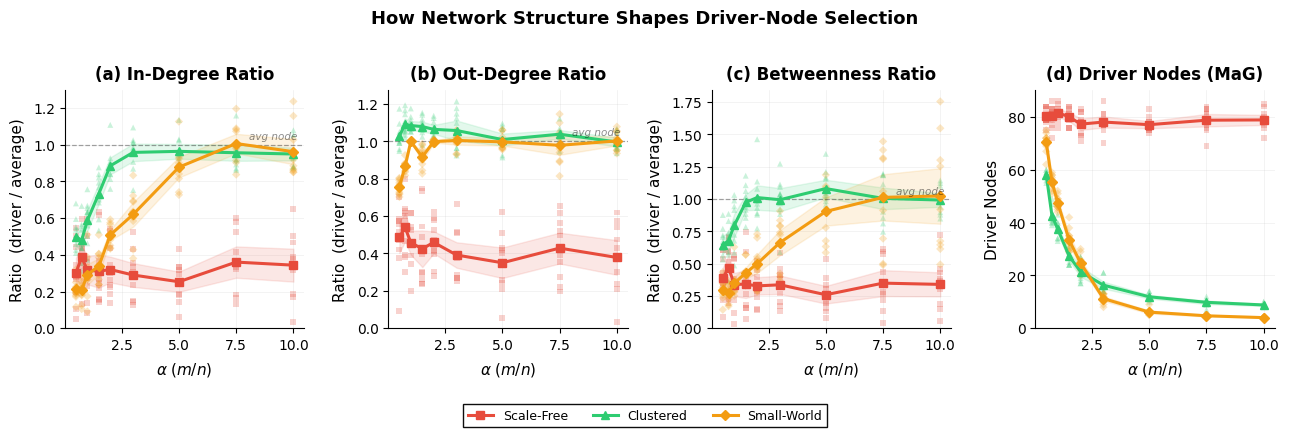

  → fig_topology_signature.{pdf,png} saved.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================================
# STYLE
# ============================================================================
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'lines.linewidth': 2.2,
    'lines.markersize': 5.5,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TOPOLOGY_ORDER  = ['scale_free', 'clustered', 'small_world']
TOPOLOGY_LABELS = {
    'scale_free':  'Scale-Free',
    'clustered':   'Clustered',
    'small_world': 'Small-World',
}
TOPOLOGY_COLORS = {
    'scale_free':  '#e74c3c',
    'clustered':   '#2ecc71',
    'small_world': '#f39c12',
}
TOPOLOGY_MARKERS = {
    'scale_free':  's',
    'clustered':   '^',
    'small_world': 'D',
}


def _plot_panel(ax, df, col, title, ylabel, show_ref_line=False):
    """
    Shared helper: draws per-trial scatter, mean line + marker, and
    shaded ±0.5 std band for every topology onto *ax*.
    """
    for topo in TOPOLOGY_ORDER:
        sub = df[df['topology'] == topo].copy()
        grouped = (sub.groupby('alpha')[col]
                   .agg(['mean', 'std'])
                   .reset_index()
                   .sort_values('alpha'))

        # individual trial scatter (behind everything else)
        ax.scatter(
            sub['alpha'], sub[col],
            color=TOPOLOGY_COLORS[topo],
            marker=TOPOLOGY_MARKERS[topo],
            alpha=0.25, s=18, zorder=1, edgecolors='none',
        )

        # mean line + markers
        ax.plot(
            grouped['alpha'], grouped['mean'],
            color=TOPOLOGY_COLORS[topo],
            marker=TOPOLOGY_MARKERS[topo],
            label=TOPOLOGY_LABELS[topo],
            zorder=3, clip_on=False,
        )

        # ±0.5 std band
        ax.fill_between(
            grouped['alpha'],
            grouped['mean'] - 0.5 * grouped['std'],
            grouped['mean'] + 0.5 * grouped['std'],
            color=TOPOLOGY_COLORS[topo], alpha=0.13,
        )

    if show_ref_line:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.35)
        ax.text(
            ax.get_xlim()[1] * 0.97, 1.02, 'avg node',
            fontsize=7.5, color='black', alpha=0.45,
            style='italic', ha='right', va='bottom',
        )

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel(r'$\alpha\;(m/n)$', labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.2)
    ax.set_axisbelow(True)


def plot_figure(summary_csv='EXP_topology.csv'):
    df = pd.read_csv(summary_csv)

    panels = [
        {'col': 'mg_ratio_in_degree',   'title': '(a) In-Degree Ratio',   'ylabel': 'Ratio  (driver / average)', 'ref': True},
        {'col': 'mg_ratio_out_degree',  'title': '(b) Out-Degree Ratio',  'ylabel': 'Ratio  (driver / average)', 'ref': True},
        {'col': 'mg_ratio_betweenness', 'title': '(c) Betweenness Ratio', 'ylabel': 'Ratio  (driver / average)', 'ref': True},
        {'col': 'greedy_size',          'title': '(d) Driver Nodes (MaG)','ylabel': 'Driver Nodes',              'ref': False},
    ]

    fig, axes = plt.subplots(1, 4, figsize=(13, 4.0), sharey=False)

    for ax, panel in zip(axes, panels):
        _plot_panel(ax, df, panel['col'], panel['title'],
                    panel['ylabel'], show_ref_line=panel['ref'])

    # shared legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center', ncol=3, frameon=True, fancybox=False,
        edgecolor='black', framealpha=0.95, fontsize=9,
        bbox_to_anchor=(0.5, -0.04),
    )

    fig.suptitle(
        'How Network Structure Shapes Driver-Node Selection',
        fontweight='bold', y=1.02,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig('fig_topology_signature.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_topology_signature.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("  → fig_topology_signature.{pdf,png} saved.")

# ============================================================================

if __name__ == "__main__":
    plot_figure('EXP_topology.csv')

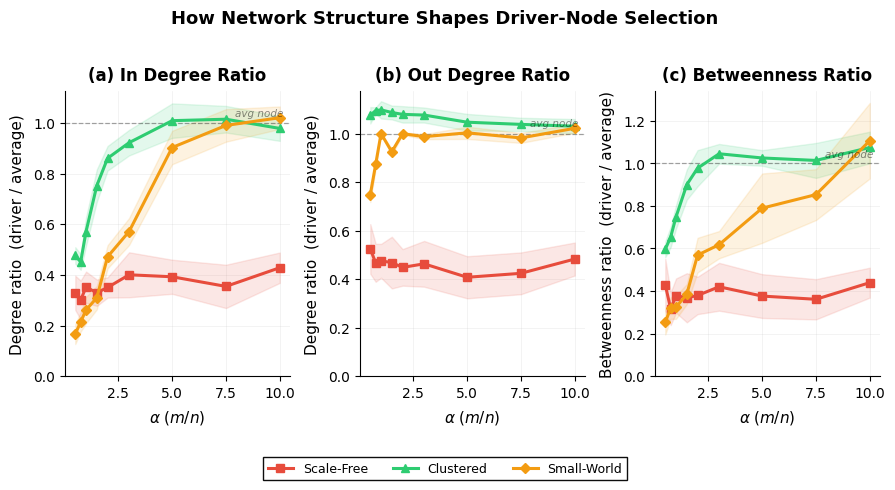

  → fig_topology_signature.{pdf,png} saved.


In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================================
# STYLE
# ============================================================================
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'lines.linewidth': 2.2,
    'lines.markersize': 5.5,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TOPOLOGY_ORDER  = ['scale_free', 'clustered', 'small_world']
TOPOLOGY_LABELS = {
    'random':      'Random',
    'scale_free':  'Scale-Free',
    'clustered':   'Clustered',
    'small_world': 'Small-World',
}
TOPOLOGY_COLORS = {
    'random':      '#3498db',
    'scale_free':  '#e74c3c',
    'clustered':   '#2ecc71',
    'small_world': '#f39c12',
}
TOPOLOGY_MARKERS = {
    'random':      'o',
    'scale_free':  's',
    'clustered':   '^',
    'small_world': 'D',
}


def plot_figure1(summary_csv='EXP_topology.csv'):
    df = pd.read_csv(summary_csv)

    # Two panels: the two metrics where topologies actually separate
    panels = [
        {'col': 'mg_ratio_in_degree',      'title': '(a) In Degree Ratio',      'ylabel': 'Degree ratio  (driver / average)'},
        {'col': 'mg_ratio_out_degree',      'title': '(b) Out Degree Ratio',      'ylabel': 'Degree ratio  (driver / average)'},
        {'col': 'mg_ratio_betweenness', 'title': '(c) Betweenness Ratio', 'ylabel': 'Betweenness ratio  (driver / average)'},
    ]

    fig, axes = plt.subplots(1, 3, figsize=(9, 4.5), sharey=False)

    for ax, panel in zip(axes, panels):
        col = panel['col']

        for topo in TOPOLOGY_ORDER:
            sub = df[df['topology'] == topo].copy()
            grouped = (sub.groupby('alpha')[col]
                       .agg(['mean', 'std'])
                       .reset_index()
                       .sort_values('alpha'))

            ax.plot(
                grouped['alpha'], grouped['mean'],
                color=TOPOLOGY_COLORS[topo],
                marker=TOPOLOGY_MARKERS[topo],
                label=TOPOLOGY_LABELS[topo],
                zorder=3,
                clip_on=False,
            )
            ax.fill_between(
                grouped['alpha'],
                grouped['mean'] - 0.5 * grouped['std'],
                grouped['mean'] + 0.5 * grouped['std'],
                color=TOPOLOGY_COLORS[topo],
                alpha=0.13,
            )

        # y = 1 reference
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.35)
        ax.text(
            ax.get_xlim()[1] * 0.97, 1.02,
            'avg node',
            fontsize=7.5, color='black', alpha=0.45,
            style='italic', ha='right', va='bottom',
        )

        ax.set_title(panel['title'], fontweight='bold', pad=8)
        ax.set_xlabel(r'$\alpha\;(m/n)$', labelpad=6)
        ax.set_ylabel(panel['ylabel'], labelpad=6)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.2)
        ax.set_axisbelow(True)

    # Single shared legend, centred below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center', ncol=4, frameon=True, fancybox=False,
        edgecolor='black', framealpha=0.95, fontsize=9,
        bbox_to_anchor=(0.5, -0.04),
    )

    fig.suptitle(
        'How Network Structure Shapes Driver-Node Selection',
        fontweight='bold', y=1.02,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig('fig_topology_signature.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_topology_signature.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("  → fig_topology_signature.{pdf,png} saved.")

# ============================================================================

if __name__ == "__main__":
    plot_figure1('EXP_topology.csv')

In [85]:
df.columns

Index(['topology', 'n', 'k', 'm', 'alpha', 'trial_id', 'matching_size',
       'greedy_size', 'pure_greedy_size', 'time_matching', 'time_mg',
       'time_pg', 'match_mean_degree', 'match_ratio_degree',
       'match_mean_closeness', 'match_ratio_closeness',
       'match_mean_betweenness', 'match_ratio_betweenness',
       'match_mean_clustering', 'match_ratio_clustering', 'mg_mean_degree',
       'mg_ratio_degree', 'mg_mean_closeness', 'mg_ratio_closeness',
       'mg_mean_betweenness', 'mg_ratio_betweenness', 'mg_mean_clustering',
       'mg_ratio_clustering', 'pg_mean_degree', 'pg_ratio_degree',
       'pg_mean_closeness', 'pg_ratio_closeness', 'pg_mean_betweenness',
       'pg_ratio_betweenness', 'pg_mean_clustering', 'pg_ratio_clustering'],
      dtype='object')

# Scratch